In [45]:
import numpy as np 


In [46]:
variant_base = np.load("/Users/vaibhav/Desktop/brahma/tree/euclid/darwin/question_generation_clustering/cluster_frequencies_qwen3-4b-base.npy")
variant1_iter2 = np.load("/Users/vaibhav/Desktop/brahma/tree/euclid/darwin/question_generation_clustering/cluster_frequencies_variant1iter3.npy")
darwin1_iter3 = np.load("/Users/vaibhav/Desktop/brahma/tree/euclid/darwin/question_generation_clustering/cluster_frequencies_variant2iter4.npy")

In [47]:
print(variant_base)
print(variant1_iter2)
print(darwin1_iter3)

[  0   1  25  10   0   1   0 118   1   4   1   1  16   0   0  43   0   0
   7   1   0   0   4  18   1   0   1   2  10   0   5  45   1   0   4   0
   4   0   8   0   9   4  16   0 261   1   8   0   2   0   0   0   1   1
  45   7  14   0   0   2   0   0   1   2  58  37   4   2   1  18   4   1
  70   1   2   3   1  17  25   1  35   0   3   0   0   0   1   5  16   0
  97  19   0   0   0   5   1   0 102   9  49  16   2  10   5   6   1   0
  13  13   1   0   2  48   3   0   1  11   1   0  17 178  12   0   5  58
   2   0]
[  0   3  75   5   0   0   0  96   0   0   0   0  79   0   0  49   0   0
   5   0   0   0   5  58   1   0   1   8   6   0   1  24   0   0   1   0
   1   0   0   0  11  19   1   0 951   0  19   0   0   0   0   0   0   2
  17   1   3   0   0   2   0   0   0   0  32  92   0   7   0  10   5   0
   4   0   0   0   0   9  34   0  14   0   0   0   0   0   1   7   6   0
 112  11   1   0   0   6   4   2 387   5  40  19   1   3   0   2   0   0
  43  14   0   0   0  73   0   1   1   9 

In [48]:
mean_variant_base = np.mean(variant_base)
mean_variant1_iter2 = np.mean(variant1_iter2)
mean_darwin1_iter2 = np.mean(darwin1_iter3)
print(mean_variant_base)
print(mean_variant1_iter2)
print(mean_darwin1_iter2)

var_variant_base = np.var(variant_base)
var_variant1_iter2 = np.var(variant1_iter2)
var_darwin1_iter2 = np.var(darwin1_iter3)
print(var_variant_base)
print(var_variant1_iter2)
print(var_darwin1_iter2)


13.265625
19.390625
22.625
1105.866943359375
8358.628662109375
1293.921875


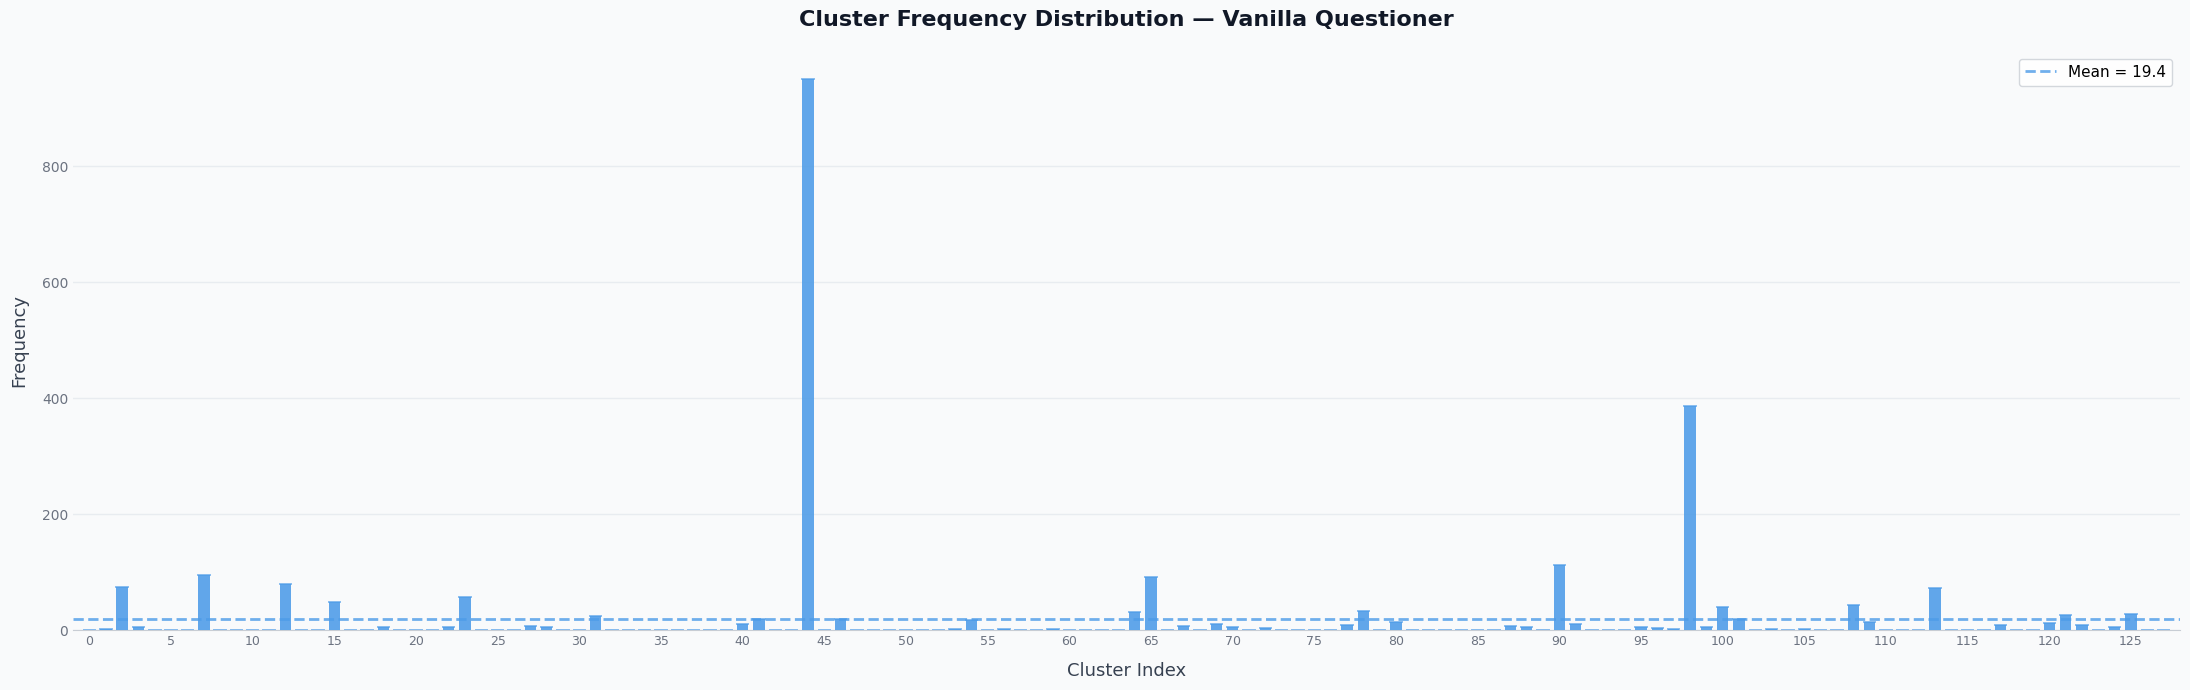

Saved → cluster_freq_vanilla.png


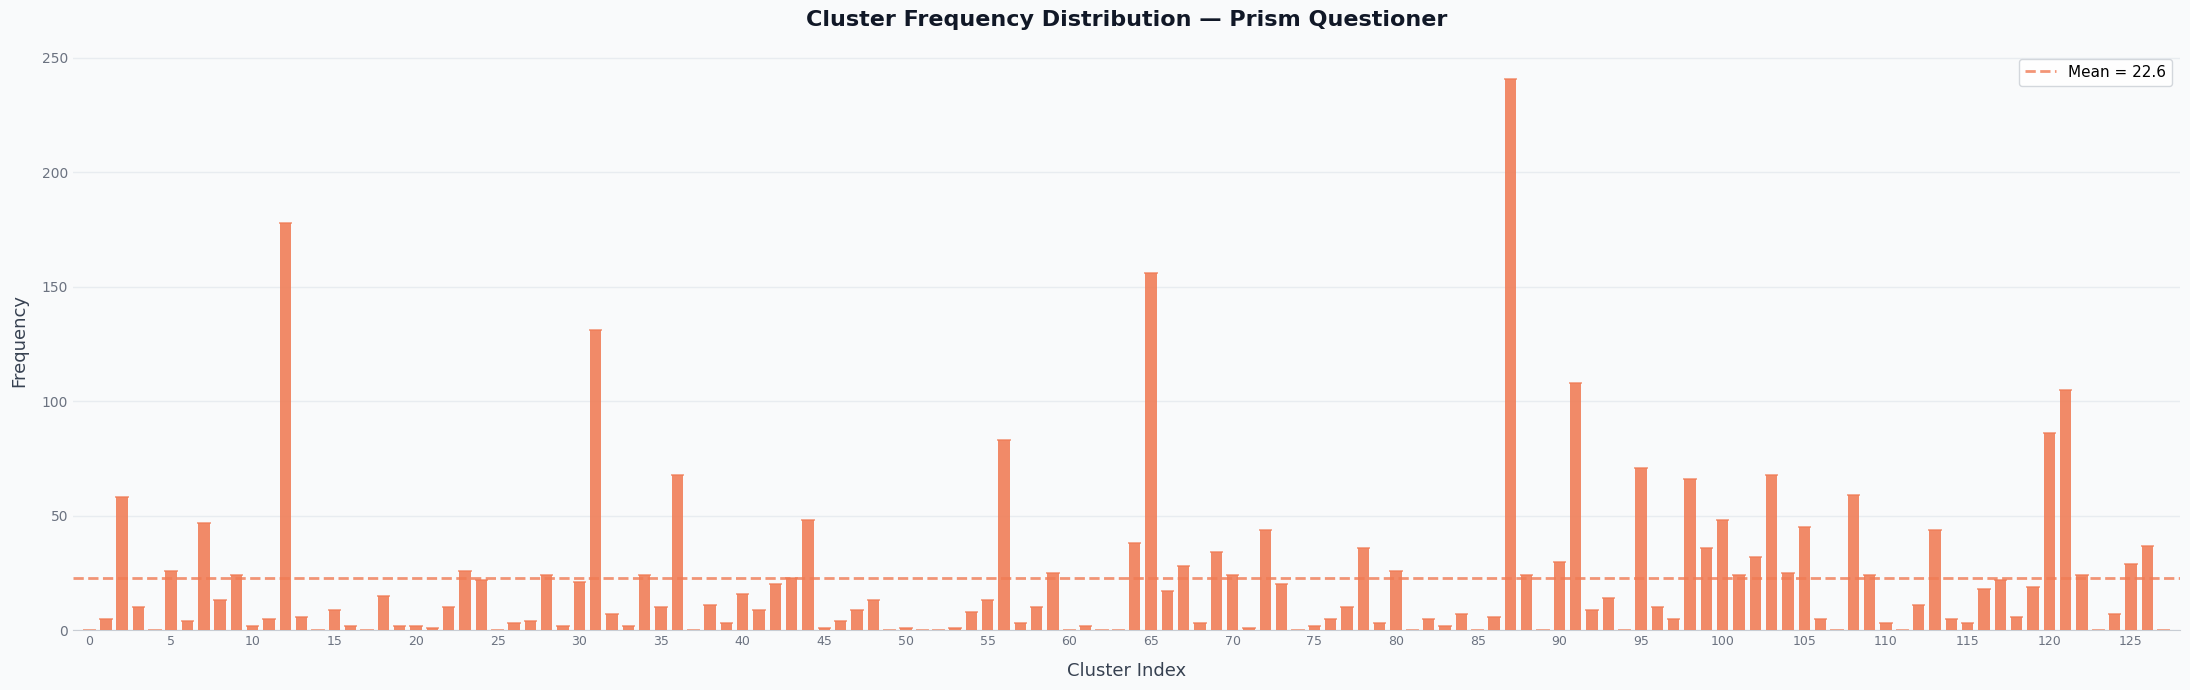

Saved → cluster_freq_prism.png


In [49]:
import matplotlib.pyplot as plt
import numpy as np

# ── shared style ──────────────────────────────────────────────────────────────
GRID_COLOR = "#E8ECF0"
BG_COLOR   = "#F9FAFB"
STEP       = 5

def plot_cluster_freq(data, mean_val, color, title, filename):
    n = len(data)
    x = np.arange(n)

    fig, ax = plt.subplots(figsize=(22, 7))
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(BG_COLOR)

    # bars
    bars = ax.bar(x, data, width=0.7, color=color, alpha=0.88, zorder=3, linewidth=0)

    # subtle top-edge highlight
    for b in bars:
        ax.plot([b.get_x(), b.get_x() + b.get_width()],
                [b.get_height(), b.get_height()],
                color=color, lw=1.4, alpha=0.65, zorder=4)

    # mean line
    ax.axhline(mean_val, color=color, lw=2.0, ls="--", alpha=0.80, zorder=5,
               label=f"Mean = {mean_val:.1f}")

    # grid & spines
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=1.0, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#C8CDD4")
    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", length=0, labelcolor="#6B7280")

    # labels & title
    ax.set_xlabel("Cluster Index", fontsize=13, color="#374151", labelpad=10)
    ax.set_ylabel("Frequency",     fontsize=13, color="#374151", labelpad=10)
    ax.set_title(title, fontsize=16, fontweight="bold", color="#111827", pad=18)

    ax.set_xticks(x[::STEP])
    ax.set_xticklabels(x[::STEP], fontsize=9, color="#6B7280")
    ax.set_xlim(-1, n)

    ax.legend(frameon=True, framealpha=0.95, edgecolor="#D1D5DB", fontsize=11, loc="upper right")

    plt.tight_layout()
    plt.savefig(filename, dpi=180, bbox_inches="tight", facecolor=BG_COLOR)
    plt.show()
    print(f"Saved → {filename}")

# ── plot 1: variant1_iter2 ────────────────────────────────────────────────────
plot_cluster_freq(
    data      = variant1_iter2,
    mean_val  = mean_variant1_iter2,
    color     = "#4C9BE8",
    title     = "Cluster Frequency Distribution — Vanilla Questioner",
    filename  = "cluster_freq_vanilla.png",
)

# ── plot 2: darwin1_iter3 ─────────────────────────────────────────────────────
plot_cluster_freq(
    data      = darwin1_iter3,
    mean_val  = mean_darwin1_iter2,
    color     = "#F07B54",
    title     = "Cluster Frequency Distribution — Prism Questioner",
    filename  = "cluster_freq_prism.png",
)